In [1]:
import pandas
import numpy
import sklearn

print("All important libraries are working!")


All important libraries are working!


In [2]:
import pandas as pd

# Load datasets
fake_df = pd.read_csv("../data/Fake.csv")
true_df = pd.read_csv("../data/True.csv")

print("Fake news samples:", fake_df.shape)
print("Real news samples:", true_df.shape)

fake_df.head()


Fake news samples: (23481, 4)
Real news samples: (21417, 4)


,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [3]:
true_df.head()


,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [4]:
fake_df["label"] = 0   # 0 = Fake
true_df["label"] = 1   # 1 = Real


In [5]:
df = pd.concat([fake_df, true_df])
df = df.sample(frac=1).reset_index(drop=True)   # shuffle

df.head()


,title,text,subject,date,label
0,Russian submarines fire cruise missiles at Isl...,MOSCOW (Reuters) - The Russian Navy on Thursda...,worldnews,"September 14, 2017",1
1,Fox & Friends Ignores FBI Director’s Trump Bo...,Fox & Friends continues to embarrass themselve...,News,"March 21, 2017",0
2,Serbia extradites Kurdish activist to Turkey d...,BELGRADE (Reuters) - Serbia has extradited to ...,worldnews,"December 26, 2017",1
3,THE VIDEO HILLARY CLINTON Does NOT Want You To...,Spread this EVERYWHERE!,left-news,"Mar 9, 2016",0
4,Illinois governor signs higher education stopg...,CHICAGO (Reuters) - Illinois Governor Bruce Ra...,politicsNews,"April 25, 2016",1


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.7+ MB


In [7]:
df["label"].value_counts()


label
0    23481
1    21417
Name: count, dtype: int64

In [8]:
df["text"][0]


'MOSCOW (Reuters) - The Russian Navy on Thursday fired seven cruise missiles at Islamic state targets in the suburbs of Syria s Deir al-Zor, the Russian Defence Ministry said in a statement on Thursday. It said the missiles were fired from two submarines in the eastern Mediterranean from a distance of 500-670 kilometers (727 miles).   The targets were command posts, communication centers, as well as militants  weapons and ammunition stockpiles in areas of south-east Deir al-Zor under the control of Islamic State,  the ministry said. '

In [9]:
df.to_csv("../data/news_dataset.csv", index=False)
print("Combined dataset saved successfully!")


Combined dataset saved successfully!


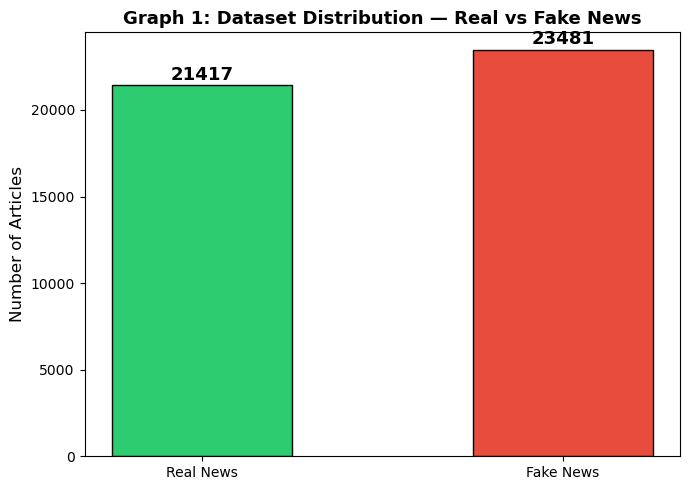

✅ Graph 1 done! Real: 21417 | Fake: 23481


In [10]:
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline

# Load Fake and True CSV files
fake_df = pd.read_csv('../data/Fake.csv')
true_df = pd.read_csv('../data/True.csv')

# Count articles
fake_count = len(fake_df)
real_count = len(true_df)

# Draw the bar chart
plt.figure(figsize=(7, 5))
bars = plt.bar(
    ['Real News', 'Fake News'],
    [real_count, fake_count],
    color=['#2ecc71', '#e74c3c'],
    edgecolor='black',
    width=0.5
)

# Add number labels on top of bars
for bar, val in zip(bars, [real_count, fake_count]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 80,
        str(val),
        ha='center', va='bottom',
        fontsize=13, fontweight='bold'
    )

plt.title('Graph 1: Dataset Distribution — Real vs Fake News',
          fontsize=13, fontweight='bold')
plt.ylabel('Number of Articles', fontsize=12)
plt.ylim(0, max(real_count, fake_count) + 1000)
plt.tight_layout()
plt.savefig('../data/graph1_dataset_distribution.png', dpi=150)
plt.show()
print(f'✅ Graph 1 done! Real: {real_count} | Fake: {fake_count}')